# Online Retail II — GenAI Product Classification

This notebook uses prompt engineering and generative AI to classify product descriptions into business-friendly product categories.

The classifications are validated, summarized, and combined with product revenue metrics to identify category-level commercial opportunities.

In [1]:
from pathlib import Path

import json
import os
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print("Pandas version:", pd.__version__)                            

Pandas version: 3.0.5


In [2]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

product_file = (
    project_root
    / "data"
    / "processed"
    / "analytics"
    / "product_performance.csv"
)

print("Project root:", project_root)
print("Product file:", product_file)
print("Product file exists:", product_file.exists())

product_performance = pd.read_csv(
    product_file,
    dtype={"stock_code": "string"}
)

print("Product records:", len(product_performance))
print("Available columns:", product_performance.columns.tolist())

product_performance.head()

Project root: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics
Product file: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\data\processed\analytics\product_performance.csv
Product file exists: True
Product records: 4725
Available columns: ['stock_code', 'gross_sales', 'units_sold', 'sales_invoices', 'known_customers', 'cancellation_value', 'cancellation_units', 'cancellation_invoices', 'description', 'estimated_net_revenue', 'cancellation_rate_pct', 'net_revenue_share_pct', 'abc_class']


,stock_code,gross_sales,units_sold,sales_invoices,known_customers,cancellation_value,cancellation_units,cancellation_invoices,description,estimated_net_revenue,cancellation_rate_pct,net_revenue_share_pct,abc_class
0,22423,"330,590.32",26478,3918,1314,"16,545.30","1,450.00",341.00,REGENCY CAKESTAND 3 TIER,"314,045.02",5.00,1.66,A
1,85123A,"261,168.73",94719,5464,1490,"9,387.10","3,637.00",134.00,WHITE HANGING HEART T-LIGHT HOLDER,"251,781.63",3.59,1.33,A
2,85099B,"182,680.98",97176,4013,978,"2,168.82","1,213.00",83.00,JUMBO BAG RED RETROSPOT,"180,512.16",1.19,0.96,A
3,47566,"148,318.28",28200,2674,894,"1,238.55",285.00,23.00,PARTY BUNTING,"147,079.73",0.84,0.78,A
4,84879,"129,324.49",80082,2807,1010,774.07,511.00,19.00,ASSORTED COLOUR BIRD ORNAMENT,"128,550.42",0.60,0.68,A


In [3]:
products = product_performance.copy()

products["classification_text"] = (
    products["description"]
    .astype("string")
    .fillna("UNKNOWN PRODUCT")
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

product_validation = pd.DataFrame(
    {
        "Check": [
            "Product records",
            "Unique stock codes",
            "Missing original descriptions",
            "Unknown classification descriptions",
            "Duplicate stock-code rows",
            "Unique classification descriptions"
        ],
        "Result": [
            len(products),
            products["stock_code"].nunique(),
            products["description"].isna().sum(),
            products["classification_text"]
            .eq("UNKNOWN PRODUCT")
            .sum(),
            products["stock_code"].duplicated().sum(),
            products["classification_text"].nunique()
        ]
    }
)

display(product_validation)

products[
    [
        "stock_code",
        "description",
        "classification_text",
        "estimated_net_revenue",
        "abc_class"
    ]
].head(10)

,Check,Result
0,Product records,4725
1,Unique stock codes,4725
2,Missing original descriptions,0
3,Unknown classification descriptions,0
4,Duplicate stock-code rows,0
5,Unique classification descriptions,4685


,stock_code,description,classification_text,estimated_net_revenue,abc_class
0,22423,REGENCY CAKESTAND 3 TIER,REGENCY CAKESTAND 3 TIER,"314,045.02",A
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,"251,781.63",A
2,85099B,JUMBO BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT,"180,512.16",A
3,47566,PARTY BUNTING,PARTY BUNTING,"147,079.73",A
4,84879,ASSORTED COLOUR BIRD ORNAMENT,ASSORTED COLOUR BIRD ORNAMENT,"128,550.42",A
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT 50'S CHRISTMAS,"116,298.59",A
6,79321,CHILLI LIGHTS,CHILLI LIGHTS,"79,905.13",A
7,22197,SMALL POPCORN HOLDER,SMALL POPCORN HOLDER,"78,903.62",A
8,22386,JUMBO BAG PINK POLKADOT,JUMBO BAG PINK POLKADOT,"75,457.64",A
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,ROTATING SILVER ANGELS T-LIGHT HLDR,"70,969.95",A


In [4]:
classification_catalog = (
    products[["classification_text"]]
    .drop_duplicates()
    .sort_values("classification_text")
    .reset_index(drop=True)
)

classification_catalog["description_id"] = (
    classification_catalog.index + 1
)

classification_catalog = classification_catalog[
    ["description_id", "classification_text"]
]

category_definitions = {
    "Kitchen & Dining": (
        "Tableware, drinkware, cookware, baking items, "
        "utensils and food-serving products."
    ),
    "Home Decor & Furnishings": (
        "Decorations, frames, mirrors, clocks, signs, "
        "ornaments, cushions and decorative furnishings."
    ),
    "Lighting & Candles": (
        "Candles, candle holders, lanterns, lamps and "
        "decorative lighting products."
    ),
    "Bags, Storage & Travel": (
        "Shopping bags, handbags, storage containers, "
        "boxes, organisers and travel accessories."
    ),
    "Seasonal & Celebrations": (
        "Christmas, Easter, birthday, wedding, party and "
        "other celebration-related products."
    ),
    "Stationery, Crafts & Wrapping": (
        "Notebooks, pens, cards, stickers, craft materials, "
        "ribbons and gift-wrapping products."
    ),
    "Toys & Children": (
        "Toys, games, children's products and "
        "child-oriented accessories."
    ),
    "Fashion & Personal Accessories": (
        "Jewellery, clothing accessories, purses, scarves "
        "and wearable personal items."
    ),
    "Garden & Outdoor": (
        "Gardening products, outdoor decorations and "
        "picnic-related products."
    ),
    "Bathroom & Personal Care": (
        "Bathroom accessories, cosmetic accessories, "
        "toiletry products and personal-care items."
    ),
    "Food & Beverage": (
        "Packaged food, tea, coffee, confectionery and "
        "other consumable products."
    ),
    "Other / Unclear": (
        "Products that cannot be confidently assigned to "
        "one of the defined categories."
    )
}

taxonomy_table = pd.DataFrame(
    {
        "product_category": category_definitions.keys(),
        "definition": category_definitions.values()
    }
)

print(
    "Descriptions requiring classification:",
    len(classification_catalog)
)

taxonomy_table

Descriptions requiring classification: 4685


,product_category,definition
0,Kitchen & Dining,"Tableware, drinkware, cookware, baking items, ..."
1,Home Decor & Furnishings,"Decorations, frames, mirrors, clocks, signs, o..."
2,Lighting & Candles,"Candles, candle holders, lanterns, lamps and d..."
3,"Bags, Storage & Travel","Shopping bags, handbags, storage containers, b..."
4,Seasonal & Celebrations,"Christmas, Easter, birthday, wedding, party an..."
5,"Stationery, Crafts & Wrapping","Notebooks, pens, cards, stickers, craft materi..."
6,Toys & Children,"Toys, games, children's products and child-ori..."
7,Fashion & Personal Accessories,"Jewellery, clothing accessories, purses, scarv..."
8,Garden & Outdoor,"Gardening products, outdoor decorations and pi..."
9,Bathroom & Personal Care,"Bathroom accessories, cosmetic accessories, to..."


In [5]:
from ollama import chat
taxonomy_prompt = "\n".join(
    [
        f"- {category}: {definition}"
        for category, definition
        in category_definitions.items()
    ]
)

classification_schema = {
    "type": "object",
    "properties": {
        "product_category": {
            "type": "string",
            "enum": list(category_definitions.keys())
        },
        "confidence": {
            "type": "string",
            "enum": ["High", "Medium", "Low"]
        },
        "reason": {
            "type": "string"
        }
    },
    "required": [
        "product_category",
        "confidence",
        "reason"
    ]
}

structured_test_response = chat(
    model="qwen3:4b",
    messages=[
        {
            "role": "system",
            "content": (
                "You are a retail product classification system.\n"
                "Classify products according to their primary "
                "functional use.\n\n"
                "Taxonomy:\n"
                f"{taxonomy_prompt}\n\n"
                "Important rules:\n"
                "- Cake stands, plates, cups and serving products "
                "belong to Kitchen & Dining.\n"
                "- Candles and light holders belong to "
                "Lighting & Candles.\n"
                "- Use Other / Unclear only when the product's "
                "function cannot be determined.\n"
                "- Keep the reason under 20 words.\n"
                "- Return only valid JSON."
            )
        },
        {
            "role": "user",
            "content": (
                "Classify this product:\n"
                "REGENCY CAKESTAND 3 TIER\n\n"
                "/no_think"
            )
        }
    ],
    format=classification_schema,
    options={
        "temperature": 0,
        "num_predict": 150
    },
    think=False
)

structured_test_result = json.loads(
    structured_test_response.message.content
)

pd.DataFrame([structured_test_result])

,product_category,confidence,reason
0,Kitchen & Dining,High,Cake stands are used for serving cakes and bel...


In [6]:
# Map description IDs back to all product records
products = products.merge(
    classification_catalog,
    on="classification_text",
    how="left",
    validate="many_to_one"
)

batch_classification_schema = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "description_id": {
                        "type": "integer"
                    },
                    "product_category": {
                        "type": "string",
                        "enum": list(category_definitions.keys())
                    },
                    "confidence": {
                        "type": "string",
                        "enum": ["High", "Medium", "Low"]
                    },
                    "reason": {
                        "type": "string"
                    }
                },
                "required": [
                    "description_id",
                    "product_category",
                    "confidence",
                    "reason"
                ]
            }
        }
    },
    "required": ["classifications"]
}


def classify_product_batch(batch_dataframe):
    batch_payload = (
        batch_dataframe[
            ["description_id", "classification_text"]
        ]
        .rename(
            columns={
                "classification_text": "product_description"
            }
        )
        .to_dict(orient="records")
    )

    system_prompt = (
        "You are a retail product classification system.\n"
        "Classify every product according to its primary "
        "functional use.\n\n"
        "Taxonomy:\n"
        f"{taxonomy_prompt}\n\n"
        "Rules:\n"
        "- Return one classification for every description_id.\n"
        "- Preserve each description_id exactly.\n"
        "- Cake stands, plates, cups and serving products are "
        "Kitchen & Dining.\n"
        "- Candles and light holders are Lighting & Candles.\n"
        "- Explicit Christmas, Easter, birthday, wedding or party "
        "products are Seasonal & Celebrations.\n"
        "- Shopping bags and storage products are "
        "Bags, Storage & Travel.\n"
        "- Classify by function rather than colour or design.\n"
        "- Use Other / Unclear only when function is unknown.\n"
        "- Keep each reason under 15 words.\n"
        "- Return only valid JSON."
    )

    response = chat(
        model="qwen3:4b",
        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": (
                    "Classify these products:\n"
                    + json.dumps(batch_payload, ensure_ascii=False)
                    + "\n\n/no_think"
                )
            }
        ],
        format=batch_classification_schema,
        options={
            "temperature": 0,
            "num_predict": 2000
        },
        think=False
    )

    parsed_response = json.loads(
        response.message.content
    )

    result = pd.DataFrame(
        parsed_response["classifications"]
    )

    result["description_id"] = (
        pd.to_numeric(result["description_id"])
        .astype(int)
    )

    expected_ids = set(
        batch_dataframe["description_id"].astype(int)
    )
    returned_ids = set(result["description_id"])

    if expected_ids != returned_ids:
        raise ValueError(
            "The model did not return every expected description ID."
        )

    return result


sample_products = (
    products.sort_values(
        "estimated_net_revenue",
        ascending=False
    )
    .drop_duplicates("description_id")
    .head(12)
)

sample_classifications = classify_product_batch(
    sample_products
)

sample_validation = (
    sample_products[
        [
            "description_id",
            "stock_code",
            "description",
            "estimated_net_revenue"
        ]
    ]
    .merge(
        sample_classifications,
        on="description_id",
        how="left",
        validate="one_to_one"
    )
)

sample_validation.style.format(
    {"estimated_net_revenue": "£{:,.2f}"}
)

,description_id,stock_code,description,estimated_net_revenue,product_category,confidence,reason
0,3306,22423,REGENCY CAKESTAND 3 TIER,"£314,045.02",Kitchen & Dining,High,Cake stands are kitchen & dining
1,4471,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£251,781.63",Lighting & Candles,High,T-Light holder is lighting & candles
2,2110,85099B,JUMBO BAG RED RETROSPOT,"£180,512.16","Bags, Storage & Travel",High,Jumbo bag is bags & storage
3,2774,47566,PARTY BUNTING,"£147,079.73",Seasonal & Celebrations,High,Party bunting is celebration product
4,246,84879,ASSORTED COLOUR BIRD ORNAMENT,"£128,550.42",Home Decor & Furnishings,High,Bird ornament is home decor
5,2748,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"£116,298.59",Seasonal & Celebrations,High,50's Christmas paper chain kit is celebration
6,880,79321,CHILLI LIGHTS,"£79,905.13",Lighting & Candles,High,Chilli lights are decorative lighting
7,3980,22197,SMALL POPCORN HOLDER,"£78,903.62",Kitchen & Dining,High,Popcorn holder is kitchen & dining
8,2108,22386,JUMBO BAG PINK POLKADOT,"£75,457.64","Bags, Storage & Travel",High,Jumbo bag is bags & storage
9,3421,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"£70,969.95",Lighting & Candles,High,T-Light holder is lighting & candles


In [7]:
from math import ceil
from pathlib import Path
import json
import time

import pandas as pd
from ollama import chat


# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------

MODEL_NAME = "qwen3:4b"
BATCH_SIZE = 10
MAX_RETRIES = 3

PRODUCT_CATEGORIES = [
    "Kitchen & Dining",
    "Home Decor & Furnishings",
    "Lighting & Candles",
    "Bags, Storage & Travel",
    "Seasonal & Celebrations",
    "Stationery, Crafts & Wrapping",
    "Toys & Children",
    "Fashion & Personal Accessories",
    "Garden & Outdoor",
    "Bathroom & Personal Care",
    "Food & Beverage",
    "Other / Unclear",
]

CONFIDENCE_LEVELS = ["High", "Medium", "Low"]


# Find the project root
if "PROJECT_ROOT" in globals():
    classification_project_root = Path(PROJECT_ROOT)
elif "project_root" in globals():
    classification_project_root = Path(project_root)
else:
    classification_project_root = Path.cwd().resolve()

    if classification_project_root.name.lower() == "notebooks":
        classification_project_root = classification_project_root.parent


analytics_directory = (
    classification_project_root
    / "data"
    / "processed"
    / "analytics"
)

analytics_directory.mkdir(parents=True, exist_ok=True)

checkpoint_path = (
    analytics_directory
    / "ollama_description_classification_checkpoint.csv"
)


# ---------------------------------------------------------
# 2. Structured output format
# ---------------------------------------------------------

production_classification_schema = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "description_id": {
                        "type": "integer"
                    },
                    "product_category": {
                        "type": "string",
                        "enum": PRODUCT_CATEGORIES
                    },
                    "confidence": {
                        "type": "string",
                        "enum": CONFIDENCE_LEVELS
                    },
                },
                "required": [
                    "description_id",
                    "product_category",
                    "confidence",
                ],
            },
        }
    },
    "required": ["classifications"],
}


# ---------------------------------------------------------
# 3. Batch-classification function
# ---------------------------------------------------------

def classify_production_batch(batch_dataframe):
    batch_records = [
        {
            "description_id": int(row.description_id),
            "description": str(row.classification_text),
        }
        for row in batch_dataframe.itertuples(index=False)
    ]

    taxonomy_text = """
Classify every retail product into exactly one category:

1. Kitchen & Dining
Tableware, drinkware, cookware, baking products, serving products,
cake stands, plates, bowls, mugs, cups, cutlery and kitchen accessories.

2. Home Decor & Furnishings
General decorations, ornaments, frames, mirrors, clocks, signs,
cushions and household decorative furnishings.

3. Lighting & Candles
Candles, candle holders, tealight holders, lanterns, lamps,
fairy lights and decorative lighting products.

4. Bags, Storage & Travel
Shopping bags, handbags, lunch bags, storage containers,
boxes, baskets and travel accessories.

5. Seasonal & Celebrations
Christmas, Easter, birthday, wedding, party and other
holiday or celebration products.

6. Stationery, Crafts & Wrapping
Notebooks, pens, cards, stickers, craft materials,
ribbons, gift wrap and packaging supplies.

7. Toys & Children
Toys, games, children's products and child-oriented items.

8. Fashion & Personal Accessories
Jewellery, clothing accessories, purses, scarves,
keyrings and personal accessories.

9. Garden & Outdoor
Gardening products, outdoor decorations, picnic items
and outdoor accessories.

10. Bathroom & Personal Care
Bathroom accessories, cosmetic accessories,
toiletry products and personal-care items.

11. Food & Beverage
Packaged food, tea, coffee, confectionery
and consumable drink products.

12. Other / Unclear
Use only when the description cannot be confidently
assigned to another category.
"""

    classification_rules = """
Important classification rules:

- Cake stands and serving products belong to Kitchen & Dining.
- T-light holders, candle holders and decorative lights belong
  to Lighting & Candles.
- Bags belong to Bags, Storage & Travel.
- Christmas and explicit holiday products belong to
  Seasonal & Celebrations.
- Party bunting belongs to Seasonal & Celebrations.
- A general bird ornament belongs to Home Decor & Furnishings
  unless it is explicitly described as a Christmas ornament.
- Return one result for every supplied description_id.
- Do not change, omit or invent description_id values.
- product_category must exactly match one supplied category.
- Return only the requested structured result.
"""

    user_prompt = f"""
{taxonomy_text}

{classification_rules}

Products to classify:

{json.dumps(batch_records, ensure_ascii=False, indent=2)}

/no_think
"""

    response = chat(
        model=MODEL_NAME,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a retail product-classification system. "
                    "Classify every supplied product and return only "
                    "the requested structured data."
                ),
            },
            {
                "role": "user",
                "content": user_prompt,
            },
        ],
        format=production_classification_schema,
        options={
            "temperature": 0,
            "num_predict": 2500,
        },
        think=False,
    )

    parsed_response = json.loads(response.message.content)

    batch_result = pd.DataFrame(
        parsed_response["classifications"]
    )

    required_columns = {
        "description_id",
        "product_category",
        "confidence",
    }

    if not required_columns.issubset(batch_result.columns):
        raise ValueError(
            "Ollama response is missing required columns."
        )

    batch_result = batch_result[
        [
            "description_id",
            "product_category",
            "confidence",
        ]
    ].copy()

    batch_result["description_id"] = pd.to_numeric(
        batch_result["description_id"],
        errors="raise",
    ).astype(int)

    expected_ids = set(
        batch_dataframe["description_id"].astype(int)
    )

    returned_ids = set(
        batch_result["description_id"].astype(int)
    )

    if (
        expected_ids != returned_ids
        or batch_result["description_id"].duplicated().any()
    ):
        raise ValueError(
            "Ollama did not return exactly one result "
            "for every description."
        )

    invalid_categories = set(
        batch_result["product_category"]
    ) - set(PRODUCT_CATEGORIES)

    if invalid_categories:
        raise ValueError(
            f"Invalid categories returned: {invalid_categories}"
        )

    invalid_confidence = set(
        batch_result["confidence"]
    ) - set(CONFIDENCE_LEVELS)

    if invalid_confidence:
        raise ValueError(
            f"Invalid confidence values returned: "
            f"{invalid_confidence}"
        )

    return batch_result


# ---------------------------------------------------------
# 4. Load an existing checkpoint, if available
# ---------------------------------------------------------

checkpoint_columns = [
    "description_id",
    "product_category",
    "confidence",
]

if checkpoint_path.exists():
    all_classifications = pd.read_csv(checkpoint_path)

    missing_checkpoint_columns = (
        set(checkpoint_columns)
        - set(all_classifications.columns)
    )

    if missing_checkpoint_columns:
        raise ValueError(
            "The checkpoint file is missing columns: "
            f"{missing_checkpoint_columns}"
        )

    all_classifications = all_classifications[
        checkpoint_columns
    ].copy()

    all_classifications["description_id"] = pd.to_numeric(
        all_classifications["description_id"],
        errors="raise",
    ).astype(int)

    all_classifications = (
        all_classifications
        .drop_duplicates(
            subset="description_id",
            keep="last",
        )
        .reset_index(drop=True)
    )
else:
    all_classifications = pd.DataFrame(
        columns=checkpoint_columns
    )


# ---------------------------------------------------------
# 5. Identify descriptions still requiring classification
# ---------------------------------------------------------

catalog_for_classification = (
    classification_catalog[
        ["description_id", "classification_text"]
    ]
    .copy()
)

catalog_for_classification["description_id"] = (
    catalog_for_classification["description_id"].astype(int)
)

valid_description_ids = set(
    catalog_for_classification["description_id"]
)

if not all_classifications.empty:
    all_classifications = all_classifications[
        all_classifications["description_id"].isin(
            valid_description_ids
        )
    ].copy()

completed_ids = set(
    all_classifications["description_id"].astype(int)
)

remaining_catalog = (
    catalog_for_classification[
        ~catalog_for_classification[
            "description_id"
        ].isin(completed_ids)
    ]
    .sort_values("description_id")
    .reset_index(drop=True)
)

total_descriptions = len(catalog_for_classification)
remaining_descriptions = len(remaining_catalog)
batches_remaining = ceil(
    remaining_descriptions / BATCH_SIZE
)


print(f"Local model: {MODEL_NAME}")
print(f"Total descriptions: {total_descriptions:,}")
print(f"Already classified: {len(completed_ids):,}")
print(f"Descriptions remaining: {remaining_descriptions:,}")
print(f"Batches remaining: {batches_remaining:,}")
print(f"Checkpoint: {checkpoint_path}")


# ---------------------------------------------------------
# 6. Run classification and save after every batch
# ---------------------------------------------------------

for batch_number, start_position in enumerate(
    range(0, remaining_descriptions, BATCH_SIZE),
    start=1,
):
    current_batch = remaining_catalog.iloc[
        start_position:start_position + BATCH_SIZE
    ].copy()

    batch_result = None
    last_error = None

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            batch_result = classify_production_batch(
                current_batch
            )
            break

        except Exception as error:
            last_error = error

            print(
                f"Batch {batch_number} attempt "
                f"{attempt}/{MAX_RETRIES} failed: {error}"
            )

            if attempt < MAX_RETRIES:
                time.sleep(5 * attempt)

    if batch_result is None:
        raise RuntimeError(
            "Classification stopped after repeated failures. "
            "The completed batches are saved. Rerun this cell "
            "to continue from the checkpoint."
        ) from last_error

    all_classifications = pd.concat(
        [all_classifications, batch_result],
        ignore_index=True,
    )

    all_classifications = (
        all_classifications
        .drop_duplicates(
            subset="description_id",
            keep="last",
        )
        .sort_values("description_id")
        .reset_index(drop=True)
    )

    temporary_checkpoint = checkpoint_path.with_name(
        checkpoint_path.name + ".tmp"
    )

    all_classifications.to_csv(
        temporary_checkpoint,
        index=False,
    )

    temporary_checkpoint.replace(checkpoint_path)

    print(
        f"Batch {batch_number:,}/{batches_remaining:,} completed | "
        f"Total saved: {len(all_classifications):,}/"
        f"{total_descriptions:,}"
    )


# ---------------------------------------------------------
# 7. Completion summary
# ---------------------------------------------------------

all_classifications = (
    all_classifications
    .sort_values("description_id")
    .reset_index(drop=True)
)

print()
print("Classification run finished.")
print(
    f"Descriptions classified: "
    f"{len(all_classifications):,}/"
    f"{total_descriptions:,}"
)

display(
    all_classifications[
        "product_category"
    ]
    .value_counts()
    .rename_axis("product_category")
    .reset_index(name="description_count")
)

Local model: qwen3:4b
Total descriptions: 4,685
Already classified: 4,685
Descriptions remaining: 0
Batches remaining: 0
Checkpoint: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\data\processed\analytics\ollama_description_classification_checkpoint.csv

Classification run finished.
Descriptions classified: 4,685/4,685


,product_category,description_count
0,Kitchen & Dining,895
1,Home Decor & Furnishings,872
2,Lighting & Candles,504
3,Fashion & Personal Accessories,472
4,"Stationery, Crafts & Wrapping",427
5,Seasonal & Celebrations,423
6,Other / Unclear,422
7,"Bags, Storage & Travel",271
8,Toys & Children,148
9,Garden & Outdoor,111


In [8]:
expected_ids = set(
    classification_catalog["description_id"].astype(int)
)

classified_ids = set(
    all_classifications["description_id"].astype(int)
)

validation_summary = pd.DataFrame({
    "Check": [
        "Classification rows",
        "Unique description IDs",
        "Duplicate description IDs",
        "Missing product categories",
        "Missing confidence values",
        "Invalid product categories",
        "Invalid confidence values",
        "Unclassified descriptions",
        "Unexpected description IDs",
    ],
    "Result": [
        len(all_classifications),
        all_classifications["description_id"].nunique(),
        all_classifications["description_id"].duplicated().sum(),
        all_classifications["product_category"].isna().sum(),
        all_classifications["confidence"].isna().sum(),
        (~all_classifications["product_category"].isin(
            PRODUCT_CATEGORIES
        )).sum(),
        (~all_classifications["confidence"].isin(
            CONFIDENCE_LEVELS
        )).sum(),
        len(expected_ids - classified_ids),
        len(classified_ids - expected_ids),
    ],
})

display(validation_summary)

confidence_summary = (
    all_classifications["confidence"]
    .value_counts()
    .rename_axis("confidence")
    .reset_index(name="description_count")
)

display(confidence_summary)

,Check,Result
0,Classification rows,4685
1,Unique description IDs,4685
2,Duplicate description IDs,0
3,Missing product categories,0
4,Missing confidence values,0
5,Invalid product categories,0
6,Invalid confidence values,0
7,Unclassified descriptions,0
8,Unexpected description IDs,0


,confidence,description_count
0,High,4304
1,Medium,275
2,Low,106


In [9]:
products_for_classification = products.drop(
    columns=[
        "description_id",
        "product_category",
        "confidence",
    ],
    errors="ignore",
)

classified_products = (
    products_for_classification
    .merge(
        classification_catalog,
        on="classification_text",
        how="left",
        validate="many_to_one",
    )
    .merge(
        all_classifications,
        on="description_id",
        how="left",
        validate="many_to_one",
    )
)

product_merge_validation = pd.DataFrame({
    "Check": [
        "Original product rows",
        "Classified product rows",
        "Unique stock codes",
        "Missing description IDs",
        "Missing product categories",
        "Missing confidence values",
    ],
    "Result": [
        len(products),
        len(classified_products),
        classified_products["stock_code"].nunique(),
        classified_products["description_id"].isna().sum(),
        classified_products["product_category"].isna().sum(),
        classified_products["confidence"].isna().sum(),
    ],
})

display(product_merge_validation)

product_preview = classified_products[
    [
        "stock_code",
        "description",
        "estimated_net_revenue",
        "product_category",
        "confidence",
    ]
].head(12).copy()

product_preview["estimated_net_revenue"] = (
    product_preview["estimated_net_revenue"]
    .map("£{:,.2f}".format)
)

display(product_preview)

,Check,Result
0,Original product rows,4725
1,Classified product rows,4725
2,Unique stock codes,4725
3,Missing description IDs,0
4,Missing product categories,0
5,Missing confidence values,0


,stock_code,description,estimated_net_revenue,product_category,confidence
0,22423,REGENCY CAKESTAND 3 TIER,"£314,045.02",Kitchen & Dining,High
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£251,781.63",Lighting & Candles,High
2,85099B,JUMBO BAG RED RETROSPOT,"£180,512.16",Kitchen & Dining,High
3,47566,PARTY BUNTING,"£147,079.73",Seasonal & Celebrations,High
4,84879,ASSORTED COLOUR BIRD ORNAMENT,"£128,550.42",Home Decor & Furnishings,High
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"£116,298.59",Seasonal & Celebrations,High
6,79321,CHILLI LIGHTS,"£79,905.13",Lighting & Candles,High
7,22197,SMALL POPCORN HOLDER,"£78,903.62",Kitchen & Dining,High
8,22386,JUMBO BAG PINK POLKADOT,"£75,457.64",Kitchen & Dining,High
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"£70,969.95",Lighting & Candles,High


In [10]:
# Rebuild the hybrid results from the original LLM output
hybrid_classified_products = classified_products.copy()

hybrid_classified_products["llm_product_category"] = (
    hybrid_classified_products["product_category"]
)

hybrid_classified_products["llm_confidence"] = (
    hybrid_classified_products["confidence"]
)

hybrid_classified_products["rule_category"] = pd.Series(
    pd.NA,
    index=hybrid_classified_products.index,
    dtype="string",
)


# Refined high-precision rules
refined_semantic_rules_v2 = [
    (
        "Seasonal & Celebrations",
        r"\b(?:CHRISTMAS|XMAS|EASTER|HALLOWEEN|ADVENT|"
        r"BIRTHDAY|WEDDING|PARTY BUNTING)\b",
    ),
    (
        "Bags, Storage & Travel",
        r"\b(?:JUMBO BAG|LUNCH BAG|LUNCH BOX|LUNCHBOX|"
        r"SHOPPER BAG|SHOPPING BAG|TOTE BAG|STORAGE BAG|"
        r"DRAWSTRING BAG|HANDBAG|BACKPACK|SUITCASE|"
        r"LUGGAGE|PICNIC BASKET)\b",
    ),
    (
        "Kitchen & Dining",
        r"\b(?:CAKESTAND|CAKE STAND|TEAPOT|DINNER PLATE|"
        r"SIDE PLATE|SOUP BOWL|MUG|CUTLERY)\b",
    ),
    (
        "Garden & Outdoor",
        r"\b(?:CITRONELLA|WATERING CAN|GARDENING|"
        r"GARDEN TOOL|GARDEN TROWEL|GARDEN SPADE|"
        r"GARDEN FORK|GARDEN GLOVE|GARDEN KNEELER|"
        r"GARDEN KNEELING|BIRDHOUSE|BIRD FEEDER)\b",
    ),
    (
        "Lighting & Candles",
        r"\b(?:T-?LIGHT|TEA ?LIGHT|TEALIGHT|CANDLE|"
        r"LANTERN|LAMP|FAIRY LIGHTS?|CHILLI LIGHTS?)\b",
    ),
]


for rule_category, pattern in refined_semantic_rules_v2:
    matching_rows = (
        hybrid_classified_products["rule_category"].isna()
        & hybrid_classified_products["description"].str.contains(
            pattern,
            case=False,
            na=False,
            regex=True,
        )
    )

    hybrid_classified_products.loc[
        matching_rows,
        "rule_category",
    ] = rule_category


rule_covered = (
    hybrid_classified_products["rule_category"].notna()
)

rule_agreement = (
    rule_covered
    & (
        hybrid_classified_products["product_category"]
        == hybrid_classified_products["rule_category"]
    )
)

rule_override = (
    rule_covered
    & (
        hybrid_classified_products["product_category"]
        != hybrid_classified_products["rule_category"]
    )
)


hybrid_classified_products["classification_method"] = (
    "LLM only"
)

hybrid_classified_products.loc[
    rule_agreement,
    "classification_method",
] = "LLM + rule agreement"

hybrid_classified_products.loc[
    rule_override,
    "classification_method",
] = "Keyword rule override"

hybrid_classified_products.loc[
    rule_override,
    "product_category",
] = hybrid_classified_products.loc[
    rule_override,
    "rule_category",
]

hybrid_classified_products.loc[
    rule_override,
    "confidence",
] = "High"


hybrid_summary_v2 = pd.DataFrame({
    "Check": [
        "Total products",
        "Products checked by refined rules",
        "LLM and rule agreements",
        "Keyword rule overrides",
        "Products classified by LLM only",
        "Missing final categories",
    ],
    "Result": [
        len(hybrid_classified_products),
        int(rule_covered.sum()),
        int(rule_agreement.sum()),
        int(rule_override.sum()),
        int((~rule_covered).sum()),
        int(
            hybrid_classified_products[
                "product_category"
            ].isna().sum()
        ),
    ],
})

display(hybrid_summary_v2)


# Verify the products that exposed the rule problem
verification_pattern = (
    r"JUMBO BAG RED RETROSPOT|"
    r"CAKE STAND 3 TIER MAGIC GARDEN|"
    r"3 HOOK HANGER MAGIC GARDEN|"
    r"BIRD HOUSE HOT WATER BOTTLE"
)

verification_results = hybrid_classified_products.loc[
    hybrid_classified_products["description"].str.contains(
        verification_pattern,
        case=False,
        na=False,
        regex=True,
    ),
    [
        "stock_code",
        "description",
        "llm_product_category",
        "rule_category",
        "product_category",
        "classification_method",
    ],
]

display(verification_results)

,Check,Result
0,Total products,4725
1,Products checked by refined rules,872
2,LLM and rule agreements,787
3,Keyword rule overrides,85
4,Products classified by LLM only,3853
5,Missing final categories,0


,stock_code,description,llm_product_category,rule_category,product_category,classification_method
2,85099B,JUMBO BAG RED RETROSPOT,Kitchen & Dining,"Bags, Storage & Travel","Bags, Storage & Travel",Keyword rule override
343,22236,CAKE STAND 3 TIER MAGIC GARDEN,Kitchen & Dining,Kitchen & Dining,Kitchen & Dining,LLM + rule agreement
509,22244,3 HOOK HANGER MAGIC GARDEN,Other / Unclear,<NA>,Other / Unclear,LLM only
530,22110,BIRD HOUSE HOT WATER BOTTLE,Bathroom & Personal Care,<NA>,Bathroom & Personal Care,LLM only


In [11]:
# Documented manual corrections discovered during QA
manual_corrections = {
    "3 HOOK HANGER MAGIC GARDEN":
        "Home Decor & Furnishings",
}


for description, corrected_category in manual_corrections.items():
    correction_mask = (
        hybrid_classified_products["description"]
        .str.upper()
        .str.strip()
        .eq(description)
    )

    hybrid_classified_products.loc[
        correction_mask,
        "product_category",
    ] = corrected_category

    hybrid_classified_products.loc[
        correction_mask,
        "confidence",
    ] = "High"

    hybrid_classified_products.loc[
        correction_mask,
        "classification_method",
    ] = "Manual QA correction"


# Review the highest-revenue products
top_revenue_review = (
    hybrid_classified_products[
        [
            "stock_code",
            "description",
            "estimated_net_revenue",
            "product_category",
            "confidence",
            "classification_method",
        ]
    ]
    .sort_values(
        "estimated_net_revenue",
        ascending=False,
    )
    .head(25)
    .copy()
)

top_revenue_review["estimated_net_revenue"] = (
    top_revenue_review["estimated_net_revenue"]
    .map("£{:,.2f}".format)
)

print("Top-revenue classification review")
display(top_revenue_review)


# Prioritize uncertain or unclear classifications for review
attention_review = (
    hybrid_classified_products[
        (
            hybrid_classified_products["confidence"]
            .isin(["Medium", "Low"])
        )
        | (
            hybrid_classified_products["product_category"]
            == "Other / Unclear"
        )
    ][
        [
            "stock_code",
            "description",
            "estimated_net_revenue",
            "product_category",
            "confidence",
            "classification_method",
        ]
    ]
    .sort_values(
        "estimated_net_revenue",
        ascending=False,
    )
    .head(30)
    .copy()
)

attention_review["estimated_net_revenue"] = (
    attention_review["estimated_net_revenue"]
    .map("£{:,.2f}".format)
)

print("High-priority manual-review candidates")
display(attention_review)

Top-revenue classification review


,stock_code,description,estimated_net_revenue,product_category,confidence,classification_method
0,22423,REGENCY CAKESTAND 3 TIER,"£314,045.02",Kitchen & Dining,High,LLM + rule agreement
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£251,781.63",Lighting & Candles,High,LLM + rule agreement
2,85099B,JUMBO BAG RED RETROSPOT,"£180,512.16","Bags, Storage & Travel",High,Keyword rule override
3,47566,PARTY BUNTING,"£147,079.73",Seasonal & Celebrations,High,LLM + rule agreement
4,84879,ASSORTED COLOUR BIRD ORNAMENT,"£128,550.42",Home Decor & Furnishings,High,LLM only
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"£116,298.59",Seasonal & Celebrations,High,LLM + rule agreement
6,79321,CHILLI LIGHTS,"£79,905.13",Lighting & Candles,High,LLM + rule agreement
7,22197,SMALL POPCORN HOLDER,"£78,903.62",Kitchen & Dining,High,LLM only
8,22386,JUMBO BAG PINK POLKADOT,"£75,457.64","Bags, Storage & Travel",High,Keyword rule override
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"£70,969.95",Lighting & Candles,High,LLM + rule agreement


High-priority manual-review candidates


,stock_code,description,estimated_net_revenue,product_category,confidence,classification_method
58,21915,RED HARMONICA IN BOX,"£41,673.54",Other / Unclear,Medium,LLM only
84,21755,LOVE BUILDING BLOCK WORD,"£34,550.42",Other / Unclear,Low,LLM only
92,15036,ASSORTED COLOURS SILK FAN,"£32,323.00",Other / Unclear,Low,LLM only
96,85014B,RED RETROSPOT UMBRELLA,"£31,162.90",Other / Unclear,High,LLM only
97,22865,HAND WARMER OWL DESIGN,"£31,151.69",Other / Unclear,Medium,LLM only
103,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,"£29,314.17",Other / Unclear,Medium,LLM only
113,22188,BLACK HEART CARD HOLDER,"£28,092.28",Other / Unclear,Medium,LLM only
115,22866,HAND WARMER SCOTTY DOG DESIGN,"£28,007.37",Other / Unclear,Medium,LLM only
132,22867,HAND WARMER BIRD DESIGN,"£25,945.43",Other / Unclear,Medium,LLM only
138,22551,PLASTERS IN TIN SPACEBOY,"£25,477.72",Other / Unclear,Medium,LLM only


In [12]:
hybrid_classified_products["qa_rule_category"] = pd.Series(
    pd.NA,
    index=hybrid_classified_products.index,
    dtype="string",
)

additional_qa_rules = [
    (
        "Bathroom & Personal Care",
        r"\b(?:HOT WATER BOTTLE|HAND WARMER|"
        r"PLASTERS IN TIN|LIP GLOSS|TISSUES)\b",
    ),
    (
        "Fashion & Personal Accessories",
        r"\b(?:UMBRELLA|PARASOL|SILK FAN|LEIS)\b",
    ),
    (
        "Toys & Children",
        r"\b(?:HARMONICA|GLIDERS?)\b",
    ),
    (
        "Stationery, Crafts & Wrapping",
        r"\b(?:MODELLING CLAY|SEWING KIT|"
        r"KNITTING NANCY)\b",
    ),
    (
        "Bags, Storage & Travel",
        r"\b(?:MINI CASES|CHARLOTTE BAG|"
        r"FOOD CONTAINER)\b",
    ),
    (
        "Home Decor & Furnishings",
        r"\b(?:CLOTHES PEGS|RECORD FRAME|"
        r"FLYING DUCKS|PIGGY BANK)\b",
    ),
]


for qa_category, pattern in additional_qa_rules:
    qa_match = (
        hybrid_classified_products[
            "classification_method"
        ].eq("LLM only")
        & hybrid_classified_products[
            "qa_rule_category"
        ].isna()
        & hybrid_classified_products[
            "description"
        ].str.contains(
            pattern,
            case=False,
            na=False,
            regex=True,
        )
    )

    qa_agreement = (
        qa_match
        & (
            hybrid_classified_products[
                "product_category"
            ] == qa_category
        )
    )

    qa_correction = (
        qa_match
        & (
            hybrid_classified_products[
                "product_category"
            ] != qa_category
        )
    )

    hybrid_classified_products.loc[
        qa_match,
        "qa_rule_category",
    ] = qa_category

    hybrid_classified_products.loc[
        qa_agreement,
        "classification_method",
    ] = "QA rule agreement"

    hybrid_classified_products.loc[
        qa_correction,
        "product_category",
    ] = qa_category

    hybrid_classified_products.loc[
        qa_correction,
        "classification_method",
    ] = "QA keyword correction"

    hybrid_classified_products.loc[
        qa_match,
        "confidence",
    ] = "High"


# Exact corrections requiring human judgement
additional_manual_corrections = {
    "LOVE BUILDING BLOCK WORD":
        "Home Decor & Furnishings",
    "BLACK HEART CARD HOLDER":
        "Home Decor & Furnishings",
}

for description, category in additional_manual_corrections.items():
    manual_mask = (
        hybrid_classified_products["description"]
        .str.upper()
        .str.strip()
        .eq(description)
    )

    hybrid_classified_products.loc[
        manual_mask,
        "product_category",
    ] = category

    hybrid_classified_products.loc[
        manual_mask,
        "confidence",
    ] = "High"

    hybrid_classified_products.loc[
        manual_mask,
        "classification_method",
    ] = "Manual QA correction"


method_summary = (
    hybrid_classified_products[
        "classification_method"
    ]
    .value_counts()
    .rename_axis("classification_method")
    .reset_index(name="product_count")
)

display(method_summary)


qa_changed_products = (
    hybrid_classified_products[
        hybrid_classified_products[
            "classification_method"
        ].isin([
            "QA keyword correction",
            "Manual QA correction",
        ])
    ][
        [
            "stock_code",
            "description",
            "llm_product_category",
            "product_category",
            "classification_method",
        ]
    ]
    .head(30)
)

display(qa_changed_products)


remaining_attention_review = (
    hybrid_classified_products[
        (
            hybrid_classified_products[
                "classification_method"
            ] == "LLM only"
        )
        & (
            hybrid_classified_products[
                "confidence"
            ].isin(["Medium", "Low"])
            | (
                hybrid_classified_products[
                    "product_category"
                ] == "Other / Unclear"
            )
        )
    ][
        [
            "stock_code",
            "description",
            "estimated_net_revenue",
            "product_category",
            "confidence",
        ]
    ]
    .sort_values(
        "estimated_net_revenue",
        ascending=False,
    )
    .head(30)
    .copy()
)

remaining_attention_review["estimated_net_revenue"] = (
    remaining_attention_review[
        "estimated_net_revenue"
    ].map("£{:,.2f}".format)
)

display(remaining_attention_review)

,classification_method,product_count
0,LLM only,3710
1,LLM + rule agreement,787
2,QA keyword correction,107
3,Keyword rule override,85
4,QA rule agreement,33
5,Manual QA correction,3


,stock_code,description,llm_product_category,product_category,classification_method
21,22114,HOT WATER BOTTLE TEA AND SYMPATHY,Kitchen & Dining,Bathroom & Personal Care,QA keyword correction
23,22112,CHOCOLATE HOT WATER BOTTLE,Kitchen & Dining,Bathroom & Personal Care,QA keyword correction
41,15056BL,EDWARDIAN PARASOL BLACK,Home Decor & Furnishings,Fashion & Personal Accessories,QA keyword correction
58,21915,RED HARMONICA IN BOX,Other / Unclear,Toys & Children,QA keyword correction
84,21755,LOVE BUILDING BLOCK WORD,Other / Unclear,Home Decor & Furnishings,Manual QA correction
92,15036,ASSORTED COLOURS SILK FAN,Other / Unclear,Fashion & Personal Accessories,QA keyword correction
96,85014B,RED RETROSPOT UMBRELLA,Other / Unclear,Fashion & Personal Accessories,QA keyword correction
97,22865,HAND WARMER OWL DESIGN,Other / Unclear,Bathroom & Personal Care,QA keyword correction
100,21479,WHITE SKULL HOT WATER BOTTLE,Kitchen & Dining,Bathroom & Personal Care,QA keyword correction
103,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,Other / Unclear,Bathroom & Personal Care,QA keyword correction


,stock_code,description,estimated_net_revenue,product_category,confidence
416,20828,GLITTER BUTTERFLY CLIPS,"£10,863.98",Other / Unclear,Low
464,22904,CALENDAR PAPER CUT DESIGN,"£9,869.15",Other / Unclear,Low
485,16014,SMALL CHINESE STYLE SCISSOR,"£9,513.10",Other / Unclear,High
496,22992,REVOLVER WOODEN RULER,"£9,180.59",Other / Unclear,Medium
531,21186,WHITE DOVE HONEYCOMB PAPER GARLAND,"£8,517.67",Other / Unclear,Medium
545,23321,SMALL WHITE HEART OF WICKER,"£8,374.19",Other / Unclear,Medium
577,21588,RETROSPOT GIANT TUBE MATCHES,"£7,684.80",Other / Unclear,High
581,21769,VINTAGE POST OFFICE CABINET,"£7,635.07",Other / Unclear,Medium
600,21746,SMALL RED RETROSPOT WINDMILL,"£7,395.84",Other / Unclear,Medium
609,22282,12 EGG HOUSE PAINTED WOOD,"£7,279.19",Other / Unclear,Low


In [13]:
priority_manual_corrections = {
    "GLITTER BUTTERFLY CLIPS":
        "Fashion & Personal Accessories",

    "CALENDAR PAPER CUT DESIGN":
        "Stationery, Crafts & Wrapping",

    "SMALL CHINESE STYLE SCISSOR":
        "Stationery, Crafts & Wrapping",

    "REVOLVER WOODEN RULER":
        "Stationery, Crafts & Wrapping",

    "WHITE DOVE HONEYCOMB PAPER GARLAND":
        "Seasonal & Celebrations",

    "SMALL WHITE HEART OF WICKER":
        "Home Decor & Furnishings",

    "RETROSPOT GIANT TUBE MATCHES":
        "Lighting & Candles",

    "VINTAGE POST OFFICE CABINET":
        "Home Decor & Furnishings",

    "SMALL RED RETROSPOT WINDMILL":
        "Garden & Outdoor",

    "12 EGG HOUSE PAINTED WOOD":
        "Kitchen & Dining",

    "LAVENDER SCENTED FABRIC HEART":
        "Home Decor & Furnishings",

    "20 DOLLY PEGS RETROSPOT":
        "Home Decor & Furnishings",

    "RED HEART SHAPE LOVE BUCKET":
        "Home Decor & Furnishings",

    "RETROSPOT CIGAR BOX MATCHES":
        "Lighting & Candles",

    "TRADITIONAL NAUGHTS & CROSSES":
        "Toys & Children",

    "SLATE TILE NATURAL HANGING":
        "Home Decor & Furnishings",

    "PACK OF 6 SWEETIE GIFT BOXES":
        "Stationery, Crafts & Wrapping",

    "INFLATABLE POLITICAL GLOBE":
        "Toys & Children",

    "COSY HOUR CIGAR BOX MATCHES":
        "Lighting & Candles",

    "KINGS CHOICE GIANT TUBE MATCHES":
        "Lighting & Candles",

    "PACK OF 12 COLOURED PENCILS":
        "Stationery, Crafts & Wrapping",

    "GLASS JAR DAISY FRESH COTTON WOOL":
        "Bathroom & Personal Care",

    "TREASURE ISLAND BOOK BOX":
        "Bags, Storage & Travel",

    "WHITE JEWELLED HEART DECORATION":
        "Home Decor & Furnishings",

    "GLASS HONEYPOT WASP CATCHER":
        "Garden & Outdoor",

    "SMALL ZINC HEART WALL ORGANISER":
        "Home Decor & Furnishings",

    "RED STAR CARD HOLDER":
        "Home Decor & Furnishings",

    "COSY HOUR GIANT TUBE MATCHES":
        "Lighting & Candles",

    "SKULLS WATER TRANSFER TATTOOS":
        "Fashion & Personal Accessories",

    "BUBBLEGUM RING ASSORTED":
        "Fashion & Personal Accessories",
}


matched_rows = 0
unmatched_descriptions = []

for description, category in priority_manual_corrections.items():
    manual_mask = (
        hybrid_classified_products["description"]
        .str.upper()
        .str.strip()
        .eq(description)
    )

    if manual_mask.any():
        matched_rows += int(manual_mask.sum())

        hybrid_classified_products.loc[
            manual_mask,
            "product_category",
        ] = category

        hybrid_classified_products.loc[
            manual_mask,
            "confidence",
        ] = "High"

        hybrid_classified_products.loc[
            manual_mask,
            "classification_method",
        ] = "Manual QA correction"

    else:
        unmatched_descriptions.append(description)


final_qa_validation = pd.DataFrame({
    "Check": [
        "Manual descriptions supplied",
        "Product rows matched",
        "Descriptions not found",
        "Missing final categories",
        "Invalid final categories",
    ],
    "Result": [
        len(priority_manual_corrections),
        matched_rows,
        len(unmatched_descriptions),
        hybrid_classified_products[
            "product_category"
        ].isna().sum(),
        (
            ~hybrid_classified_products[
                "product_category"
            ].isin(PRODUCT_CATEGORIES)
        ).sum(),
    ],
})

display(final_qa_validation)


final_method_summary = (
    hybrid_classified_products[
        "classification_method"
    ]
    .value_counts()
    .rename_axis("classification_method")
    .reset_index(name="product_count")
)

display(final_method_summary)


final_category_counts = (
    hybrid_classified_products[
        "product_category"
    ]
    .value_counts()
    .rename_axis("product_category")
    .reset_index(name="product_count")
)

display(final_category_counts)

,Check,Result
0,Manual descriptions supplied,30
1,Product rows matched,30
2,Descriptions not found,0
3,Missing final categories,0
4,Invalid final categories,0


,classification_method,product_count
0,LLM only,3680
1,LLM + rule agreement,787
2,QA keyword correction,107
3,Keyword rule override,85
4,QA rule agreement,33
5,Manual QA correction,33


,product_category,product_count
0,Home Decor & Furnishings,894
1,Kitchen & Dining,859
2,Lighting & Candles,518
3,Fashion & Personal Accessories,506
4,Seasonal & Celebrations,452
5,"Stationery, Crafts & Wrapping",430
6,Other / Unclear,324
7,"Bags, Storage & Travel",287
8,Bathroom & Personal Care,155
9,Toys & Children,146


In [14]:
import numpy as np


category_performance = (
    hybrid_classified_products
    .groupby(
        "product_category",
        as_index=False,
    )
    .agg(
        product_count=("stock_code", "nunique"),
        gross_sales=("gross_sales", "sum"),
        cancellation_value=("cancellation_value", "sum"),
        estimated_net_revenue=(
            "estimated_net_revenue",
            "sum",
        ),
        units_sold=("units_sold", "sum"),
        sales_invoices=("sales_invoices", "sum"),
        a_class_products=(
            "abc_class",
            lambda values: (
                values.astype(str).str.upper() == "A"
            ).sum(),
        ),
    )
)


total_products = (
    category_performance["product_count"].sum()
)

total_net_revenue = (
    category_performance[
        "estimated_net_revenue"
    ].sum()
)


category_performance["product_share_pct"] = (
    category_performance["product_count"]
    .div(total_products)
    .mul(100)
)

category_performance["net_revenue_share_pct"] = (
    category_performance["estimated_net_revenue"]
    .div(total_net_revenue)
    .mul(100)
)

category_performance["cancellation_rate_pct"] = (
    category_performance["cancellation_value"]
    .div(category_performance["gross_sales"])
    .mul(100)
)

category_performance[
    "average_net_revenue_per_product"
] = (
    category_performance["estimated_net_revenue"]
    .div(category_performance["product_count"])
)


category_performance = (
    category_performance
    .sort_values(
        "estimated_net_revenue",
        ascending=False,
    )
    .reset_index(drop=True)
)


# Confirm that aggregation did not change the totals
revenue_reconciliation = pd.DataFrame({
    "Check": [
        "Source product rows",
        "Category product count",
        "Source gross sales",
        "Category gross sales",
        "Source cancellation value",
        "Category cancellation value",
        "Source estimated net revenue",
        "Category estimated net revenue",
        "Net revenue difference",
        "Category revenue share total",
    ],
    "Result": [
        len(hybrid_classified_products),
        category_performance[
            "product_count"
        ].sum(),
        hybrid_classified_products[
            "gross_sales"
        ].sum(),
        category_performance[
            "gross_sales"
        ].sum(),
        hybrid_classified_products[
            "cancellation_value"
        ].sum(),
        category_performance[
            "cancellation_value"
        ].sum(),
        hybrid_classified_products[
            "estimated_net_revenue"
        ].sum(),
        category_performance[
            "estimated_net_revenue"
        ].sum(),
        (
            category_performance[
                "estimated_net_revenue"
            ].sum()
            - hybrid_classified_products[
                "estimated_net_revenue"
            ].sum()
        ),
        category_performance[
            "net_revenue_share_pct"
        ].sum(),
    ],
})

display(revenue_reconciliation)


# Create a formatted display copy
category_performance_display = (
    category_performance.copy()
)

currency_columns = [
    "gross_sales",
    "cancellation_value",
    "estimated_net_revenue",
    "average_net_revenue_per_product",
]

percentage_columns = [
    "product_share_pct",
    "net_revenue_share_pct",
    "cancellation_rate_pct",
]

for column in currency_columns:
    category_performance_display[column] = (
        category_performance_display[column]
        .map("£{:,.2f}".format)
    )

for column in percentage_columns:
    category_performance_display[column] = (
        category_performance_display[column]
        .map("{:.2f}%".format)
    )

display(category_performance_display)

,Check,Result
0,Source product rows,"4,725.00"
1,Category product count,"4,725.00"
2,Source gross sales,"19,604,891.64"
3,Category gross sales,"19,604,891.64"
4,Source cancellation value,"716,198.69"
5,Category cancellation value,"716,198.69"
6,Source estimated net revenue,"18,888,692.95"
7,Category estimated net revenue,"18,888,692.95"
8,Net revenue difference,0.00
9,Category revenue share total,100.00


,product_category,product_count,gross_sales,cancellation_value,estimated_net_revenue,units_sold,sales_invoices,a_class_products,product_share_pct,net_revenue_share_pct,cancellation_rate_pct,average_net_revenue_per_product
0,Kitchen & Dining,859,"£4,508,217.58","£211,291.10","£4,296,926.48",2523629,223449,272,18.18%,22.75%,4.69%,"£5,002.24"
1,Home Decor & Furnishings,894,"£4,017,639.83","£248,119.15","£3,769,520.68",1617754,179084,190,18.92%,19.96%,6.18%,"£4,216.47"
2,"Bags, Storage & Travel",287,"£2,657,326.96","£49,776.24","£2,607,550.72",1385077,125100,114,6.07%,13.80%,1.87%,"£9,085.54"
3,Seasonal & Celebrations,452,"£1,827,710.55","£40,096.55","£1,787,614.00",1102681,97235,112,9.57%,9.46%,2.19%,"£3,954.90"
4,Lighting & Candles,518,"£1,809,545.50","£72,015.55","£1,737,529.95",1023991,74348,78,10.96%,9.20%,3.98%,"£3,354.30"
5,"Stationery, Crafts & Wrapping",430,"£1,582,149.73","£35,771.29","£1,546,378.44",1429075,101732,100,9.10%,8.19%,2.26%,"£3,596.23"
6,Bathroom & Personal Care,155,"£1,100,565.51","£16,802.35","£1,083,763.16",649834,56508,60,3.28%,5.74%,1.53%,"£6,992.02"
7,Toys & Children,146,"£684,969.64","£16,792.84","£668,176.80",526073,42435,46,3.09%,3.54%,2.45%,"£4,576.55"
8,Fashion & Personal Accessories,506,"£662,528.61","£11,211.08","£651,317.53",420507,36496,34,10.71%,3.45%,1.69%,"£1,287.19"
9,Garden & Outdoor,123,"£344,781.08","£5,369.56","£339,411.52",168243,22924,21,2.60%,1.80%,1.56%,"£2,759.44"


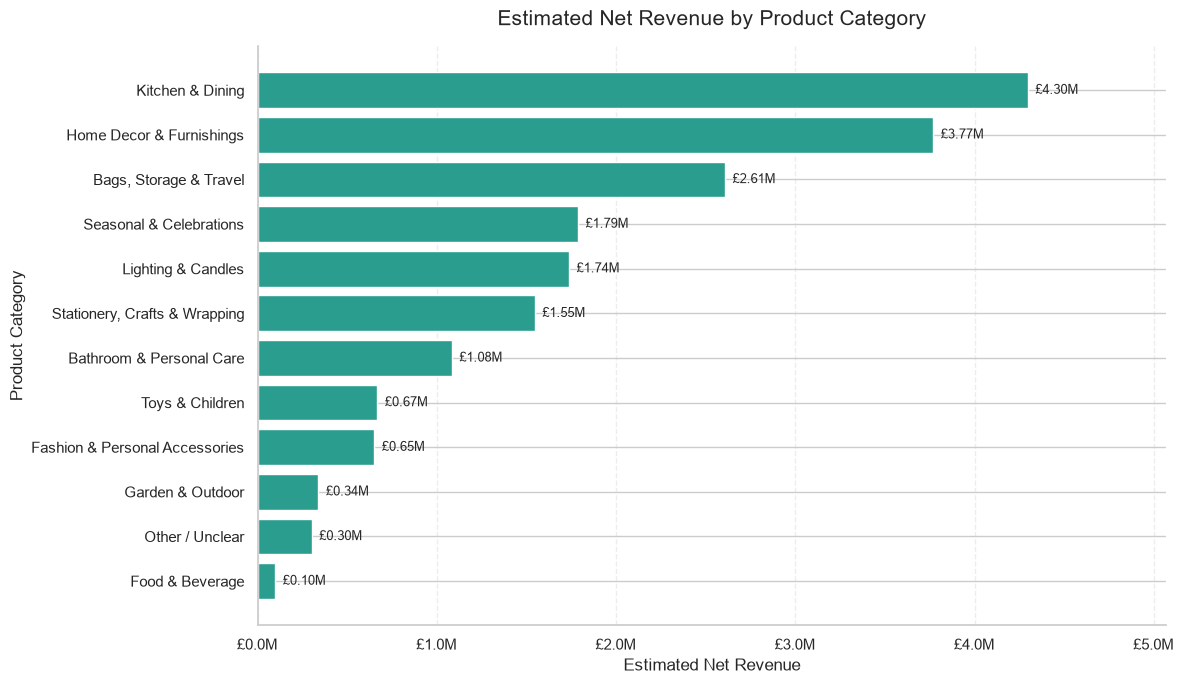

Chart saved to: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\screenshots\genai_category_net_revenue.png


In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


screenshots_directory = project_root / "screenshots"
screenshots_directory.mkdir(
    parents=True,
    exist_ok=True,
)

revenue_plot_data = (
    category_performance
    .sort_values(
        "estimated_net_revenue",
        ascending=True,
    )
)


fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    revenue_plot_data["product_category"],
    revenue_plot_data["estimated_net_revenue"],
    color="#2A9D8F",
)

ax.set_title(
    "Estimated Net Revenue by Product Category",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Estimated Net Revenue")
ax.set_ylabel("Product Category")

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
            f"£{value / 1_000_000:.1f}M"
    )
)

maximum_revenue = revenue_plot_data[
    "estimated_net_revenue"
].max()

ax.set_xlim(0, maximum_revenue * 1.18)

for bar, revenue in zip(
    bars,
    revenue_plot_data["estimated_net_revenue"],
):
    ax.text(
        revenue + maximum_revenue * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"£{revenue / 1_000_000:.2f}M",
        va="center",
        fontsize=9,
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

chart_path = (
    screenshots_directory
    / "genai_category_net_revenue.png"
)

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved to: {chart_path}")

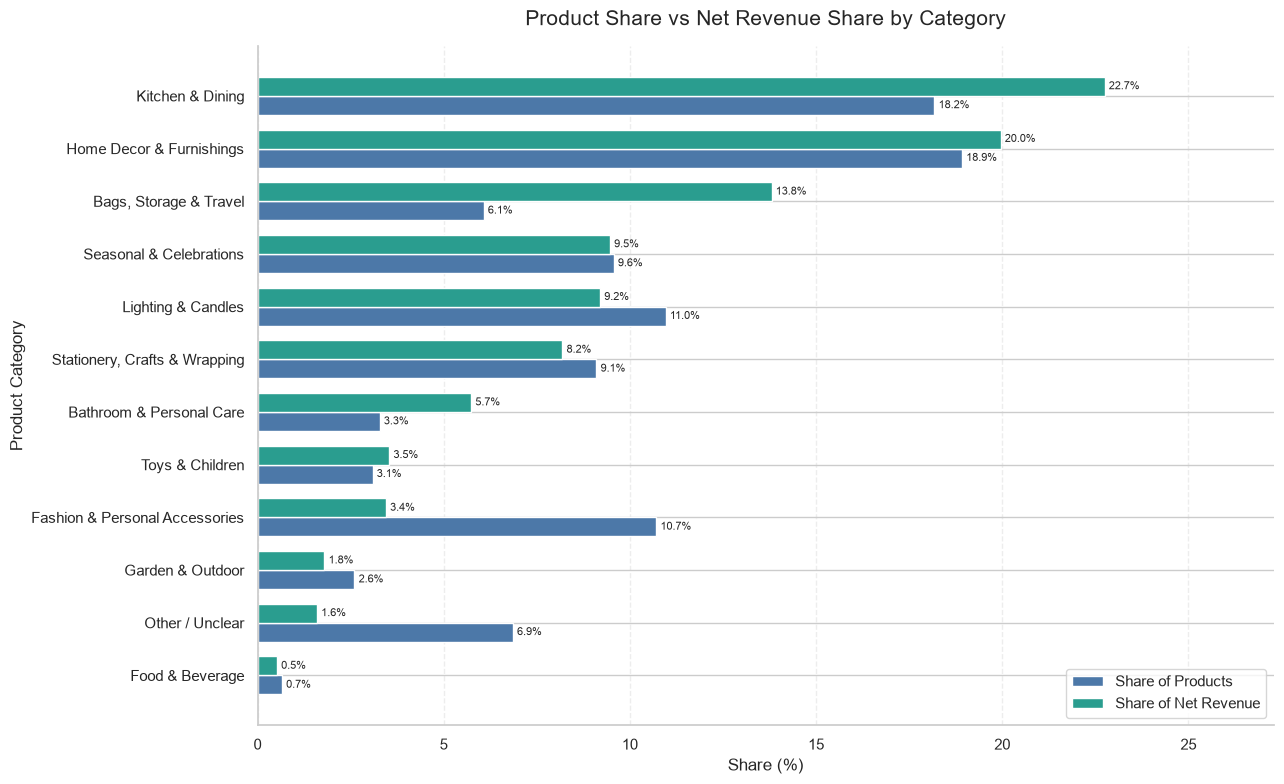

Chart saved to: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\screenshots\genai_product_vs_revenue_share.png


In [16]:
import numpy as np
import matplotlib.pyplot as plt


share_plot_data = (
    category_performance
    .sort_values(
        "net_revenue_share_pct",
        ascending=True,
    )
    .reset_index(drop=True)
)

positions = np.arange(len(share_plot_data))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(13, 8))

product_bars = ax.barh(
    positions - bar_height / 2,
    share_plot_data["product_share_pct"],
    height=bar_height,
    label="Share of Products",
    color="#4C78A8",
)

revenue_bars = ax.barh(
    positions + bar_height / 2,
    share_plot_data["net_revenue_share_pct"],
    height=bar_height,
    label="Share of Net Revenue",
    color="#2A9D8F",
)

ax.set_yticks(positions)
ax.set_yticklabels(
    share_plot_data["product_category"]
)

ax.set_title(
    "Product Share vs Net Revenue Share by Category",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Share (%)")
ax.set_ylabel("Product Category")

maximum_share = max(
    share_plot_data["product_share_pct"].max(),
    share_plot_data["net_revenue_share_pct"].max(),
)

ax.set_xlim(0, maximum_share * 1.20)

ax.bar_label(
    product_bars,
    labels=[
        f"{value:.1f}%"
        for value in share_plot_data[
            "product_share_pct"
        ]
    ],
    padding=3,
    fontsize=8,
)

ax.bar_label(
    revenue_bars,
    labels=[
        f"{value:.1f}%"
        for value in share_plot_data[
            "net_revenue_share_pct"
        ]
    ],
    padding=3,
    fontsize=8,
)

ax.legend(
    loc="lower right",
    frameon=True,
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

comparison_chart_path = (
    screenshots_directory
    / "genai_product_vs_revenue_share.png"
)

fig.savefig(
    comparison_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Chart saved to: {comparison_chart_path}"
)

In [17]:
# ---------------------------------------------------------
# Final GenAI classification exports
# ---------------------------------------------------------

export_directory = (
    project_root
    / "data"
    / "processed"
    / "analytics"
)

export_directory.mkdir(
    parents=True,
    exist_ok=True,
)


# Confirm identical descriptions do not have conflicting categories
description_category_conflicts = (
    hybrid_classified_products
    .groupby("description_id")["product_category"]
    .nunique()
    .gt(1)
    .sum()
)


# Product-level final dataset
product_export_columns = [
    "stock_code",
    "description",
    "classification_text",
    "description_id",
    "product_category",
    "confidence",
    "classification_method",
    "llm_product_category",
    "llm_confidence",
    "rule_category",
    "qa_rule_category",
    "gross_sales",
    "cancellation_value",
    "estimated_net_revenue",
    "units_sold",
    "sales_invoices",
    "known_customers",
    "abc_class",
]

final_product_classifications = (
    hybrid_classified_products[
        product_export_columns
    ]
    .sort_values(
        "estimated_net_revenue",
        ascending=False,
    )
    .reset_index(drop=True)
)


# Description-level dataset
description_export_columns = [
    "description_id",
    "classification_text",
    "description",
    "product_category",
    "confidence",
    "classification_method",
    "llm_product_category",
    "llm_confidence",
    "rule_category",
    "qa_rule_category",
]

final_description_classifications = (
    hybrid_classified_products[
        description_export_columns
    ]
    .sort_values("description_id")
    .drop_duplicates(
        subset="description_id",
        keep="first",
    )
    .reset_index(drop=True)
)


# Final validation summary
final_validation_summary = pd.DataFrame({
    "metric": [
        "Product classification rows",
        "Unique stock codes",
        "Description classification rows",
        "Unique description IDs",
        "Description category conflicts",
        "Missing product categories",
        "Invalid product categories",
        "Other / Unclear products",
        "Other / Unclear product share pct",
        "LLM-only products",
        "Rule or QA-supported products",
        "Category revenue share total pct",
    ],
    "result": [
        len(final_product_classifications),
        final_product_classifications[
            "stock_code"
        ].nunique(),
        len(final_description_classifications),
        final_description_classifications[
            "description_id"
        ].nunique(),
        int(description_category_conflicts),
        int(
            final_product_classifications[
                "product_category"
            ].isna().sum()
        ),
        int(
            (
                ~final_product_classifications[
                    "product_category"
                ].isin(PRODUCT_CATEGORIES)
            ).sum()
        ),
        int(
            (
                final_product_classifications[
                    "product_category"
                ] == "Other / Unclear"
            ).sum()
        ),
        round(
            (
                final_product_classifications[
                    "product_category"
                ] == "Other / Unclear"
            ).mean() * 100,
            2,
        ),
        int(
            (
                final_product_classifications[
                    "classification_method"
                ] == "LLM only"
            ).sum()
        ),
        int(
            (
                final_product_classifications[
                    "classification_method"
                ] != "LLM only"
            ).sum()
        ),
        round(
            category_performance[
                "net_revenue_share_pct"
            ].sum(),
            2,
        ),
    ],
})


# Classification-method summary
classification_method_summary = (
    final_product_classifications[
        "classification_method"
    ]
    .value_counts()
    .rename_axis("classification_method")
    .reset_index(name="product_count")
)

classification_method_summary[
    "product_share_pct"
] = (
    classification_method_summary[
        "product_count"
    ]
    .div(len(final_product_classifications))
    .mul(100)
    .round(2)
)


# Taxonomy documentation
product_taxonomy = pd.DataFrame({
    "product_category": PRODUCT_CATEGORIES,
    "definition": [
        "Tableware, drinkware, cookware, baking and serving products.",
        "Decorations, ornaments, frames, mirrors and household furnishings.",
        "Candles, holders, lanterns, lamps and decorative lighting.",
        "Shopping bags, storage products, containers and travel accessories.",
        "Christmas, Easter, birthday, wedding and party products.",
        "Stationery, cards, craft materials, wrapping and packaging supplies.",
        "Toys, games and child-oriented products.",
        "Jewellery, clothing and personal fashion accessories.",
        "Gardening products, outdoor decorations and accessories.",
        "Bathroom, toiletry, cosmetic and personal-care products.",
        "Food, tea, coffee, confectionery and consumable beverages.",
        "Products that cannot be confidently assigned elsewhere.",
    ],
})


# Export paths
export_files = {
    "Product classifications":
        export_directory
        / "genai_product_classifications.csv",

    "Description classifications":
        export_directory
        / "genai_description_classifications.csv",

    "Category performance":
        export_directory
        / "genai_category_performance.csv",

    "Validation summary":
        export_directory
        / "genai_classification_validation.csv",

    "Method summary":
        export_directory
        / "genai_classification_method_summary.csv",

    "Product taxonomy":
        export_directory
        / "product_taxonomy.csv",
}


# Write the files
final_product_classifications.to_csv(
    export_files["Product classifications"],
    index=False,
)

final_description_classifications.to_csv(
    export_files["Description classifications"],
    index=False,
)

category_performance.to_csv(
    export_files["Category performance"],
    index=False,
)

final_validation_summary.to_csv(
    export_files["Validation summary"],
    index=False,
)

classification_method_summary.to_csv(
    export_files["Method summary"],
    index=False,
)

product_taxonomy.to_csv(
    export_files["Product taxonomy"],
    index=False,
)


# Export confirmation
export_confirmation = pd.DataFrame([
    {
        "export": export_name,
        "file": str(file_path),
        "rows": len(pd.read_csv(file_path)),
        "size_kb": round(
            file_path.stat().st_size / 1024,
            2,
        ),
    }
    for export_name, file_path in export_files.items()
])

display(final_validation_summary)
display(export_confirmation)

print("GenAI classification exports completed successfully.")

,metric,result
0,Product classification rows,"4,725.00"
1,Unique stock codes,"4,725.00"
2,Description classification rows,"4,685.00"
3,Unique description IDs,"4,685.00"
4,Description category conflicts,0.00
5,Missing product categories,0.00
6,Invalid product categories,0.00
7,Other / Unclear products,324.00
8,Other / Unclear product share pct,6.86
9,LLM-only products,"3,680.00"


,export,file,rows,size_kb
0,Product classifications,c:\Users\hp\Documents\Customer-Revenue-Retenti...,4725,819.34
1,Description classifications,c:\Users\hp\Documents\Customer-Revenue-Retenti...,4685,621.85
2,Category performance,c:\Users\hp\Documents\Customer-Revenue-Retenti...,12,1.95
3,Validation summary,c:\Users\hp\Documents\Customer-Revenue-Retenti...,12,0.42
4,Method summary,c:\Users\hp\Documents\Customer-Revenue-Retenti...,6,0.22
5,Product taxonomy,c:\Users\hp\Documents\Customer-Revenue-Retenti...,12,1.01


GenAI classification exports completed successfully.


## Final GenAI Product Classification Summary

This analysis classified 4,685 unique product descriptions covering
4,725 stock codes into a structured 12-category retail taxonomy.

### Methodology

- Qwen3:4B was executed locally using Ollama.
- Structured JSON output ensured consistent category and confidence fields.
- Checkpointing allowed interrupted classification runs to resume safely.
- High-precision keyword rules validated and corrected explicit product types.
- High-revenue and uncertain classifications received targeted manual QA.
- Original LLM classifications were retained for auditability.

### Final Validation

- Product records classified: **4,725**
- Unique descriptions classified: **4,685**
- Missing classifications: **0**
- Conflicting description classifications: **0**
- Rule or QA-supported products: **1,045**
- Other / Unclear products: **324 (6.86%)**

### Business Findings

- Kitchen & Dining generated **£4.30M**, representing **22.75%**
  of estimated net revenue.
- Home Decor & Furnishings generated **£3.77M**, representing
  **19.96%** of estimated net revenue.
- Bags, Storage & Travel generated **13.80%** of revenue from only
  **6.07%** of products, indicating strong category productivity.
- Bathroom & Personal Care also generated a larger revenue share
  than its product share.
- Fashion & Personal Accessories represented **10.71%** of products
  but only **3.45%** of estimated net revenue.
- Other / Unclear products contributed only **1.60%** of estimated
  net revenue, limiting the financial impact of remaining ambiguity.

### Output Files

- `genai_product_classifications.csv`
- `genai_description_classifications.csv`
- `genai_category_performance.csv`
- `genai_classification_validation.csv`
- `genai_classification_method_summary.csv`
- `product_taxonomy.csv`

### Limitation

LLM confidence is self-reported and does not guarantee semantic accuracy.
The final workflow therefore combines LLM classification, deterministic
rules and targeted manual review.